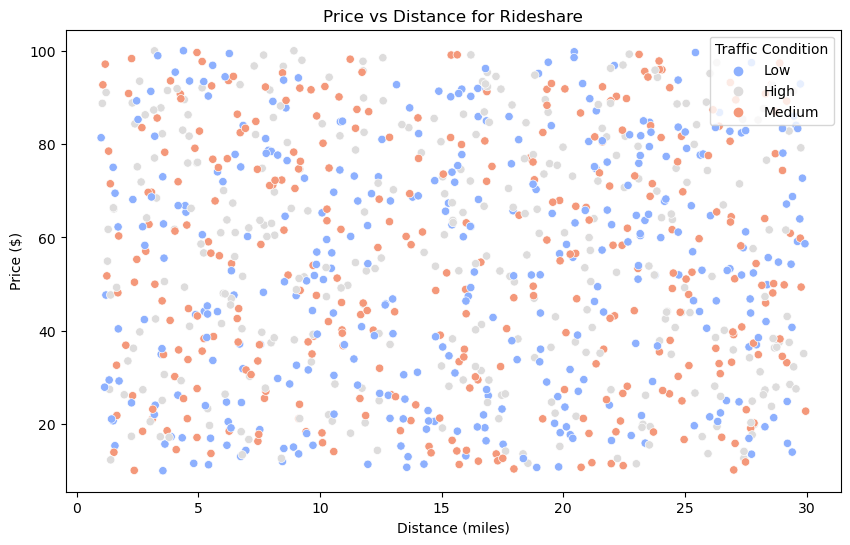

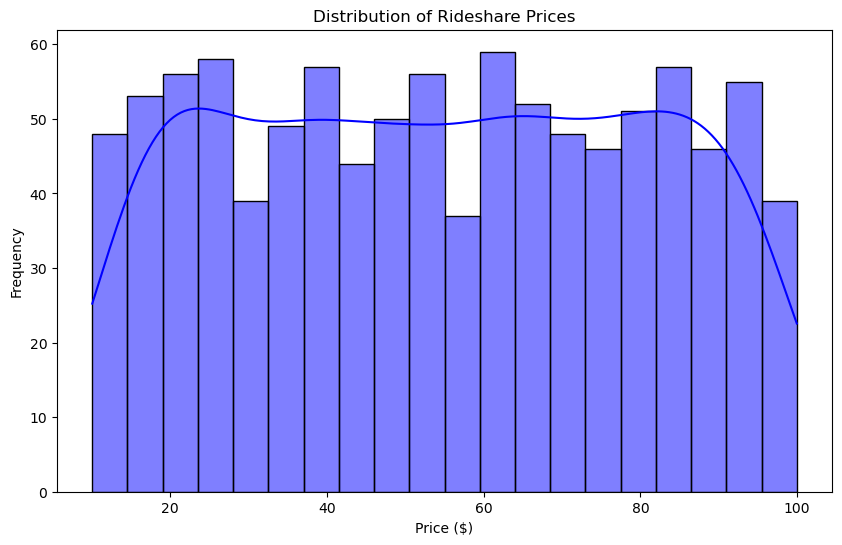

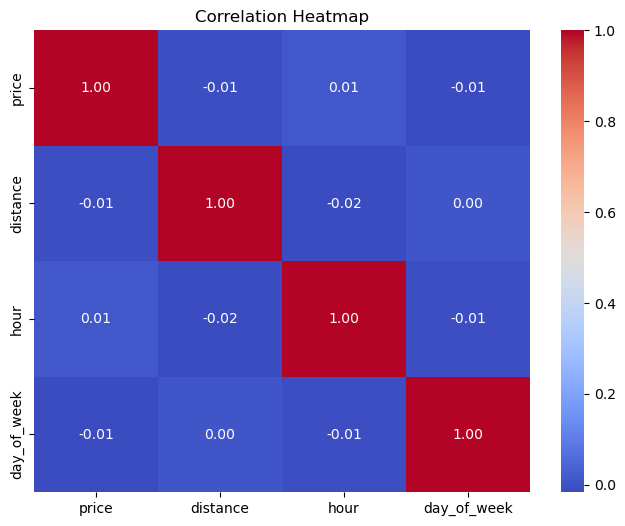

            Date/Time      price   distance  hour  day_of_week  \
0 2023-01-01 00:00:00  65.413061   4.489804     0            6   
1 2023-01-01 01:00:00  39.402226  12.998437     1            6   
2 2023-01-01 02:00:00  26.238384  17.466851     2            6   
3 2023-01-01 03:00:00  91.733074  15.827178     3            6   
4 2023-01-01 04:00:00  84.644298  23.550051     4            6   

   pickup_location_Suburbs  pickup_location_Uptown  dropoff_location_Suburbs  \
0                     True                   False                      True   
1                    False                    True                      True   
2                    False                    True                     False   
3                    False                   False                     False   
4                    False                   False                     False   

   dropoff_location_Uptown  traffic_condition_Low  traffic_condition_Medium  
0                    False                  

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Simulated example data
data = {
    'Date/Time': pd.date_range(start="2023-01-01", periods=1000, freq='H'),
    'pickup_location': np.random.choice(['Downtown', 'Uptown', 'Suburbs'], 1000),
    'dropoff_location': np.random.choice(['Downtown', 'Uptown', 'Suburbs'], 1000),
    'price': np.random.uniform(10, 100, 1000),  # random prices between 10 and 100
    'distance': np.random.uniform(1, 30, 1000),  # random distance in miles
    'traffic_condition': np.random.choice(['Low', 'Medium', 'High'], 1000)
}

# Load data into DataFrame
df = pd.DataFrame(data)

# Convert Date/Time to datetime object
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

# Feature Engineering
df['hour'] = df['Date/Time'].dt.hour  # Extract hour from Date/Time for potential patterns
df['day_of_week'] = df['Date/Time'].dt.dayofweek  # Day of the week (0=Monday, 6=Sunday)

# Visualizing price vs distance
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='distance', y='price', hue='traffic_condition', palette='coolwarm')
plt.title('Price vs Distance for Rideshare')
plt.xlabel('Distance (miles)')
plt.ylabel('Price ($)')
plt.legend(title='Traffic Condition')
plt.show()

# Visualize price distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, color='blue', bins=20)
plt.title('Distribution of Rideshare Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

# Heatmap to show correlation between features
correlation_matrix = df[['price', 'distance', 'hour', 'day_of_week']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Encoding categorical variables for model input
df_encoded = pd.get_dummies(df, columns=['pickup_location', 'dropoff_location', 'traffic_condition'], drop_first=True)

# Sample of the processed dataset
print(df_encoded.head())
